# Load QM9 Dataset

In [1]:
import os
from pathlib import Path
from torch_geometric.datasets import QM9

DATA_ROOT = Path.cwd().parent / "data" / "QM9"

dataset = QM9(DATA_ROOT)

/home/doterog/repos/uva/research/drifting-experiments/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/doterog/repos/uva/research/drifting-experiments/.venv/lib/python3.11/site-packages/torch_geometric/data/dataset.py:115: UserWarning: The `pre_transform` argument differs from the one used in the pre-processed version of this dataset. If you want to make use of another pre-processing technique, pass `force_reload=True` explicitly to reload the dataset.
  self._process()


# Define MLP, Loss, and Training Loop

- Reminder: norm_diff and node_attr are dead params
- We are missing the normalization factor that is passed with the sum of both GCNs

In [75]:
import torch
from torch import nn
from torch_geometric.nn import MessagePassing

class TypeGCN(MessagePassing):
    propagate_type = {"type_feat": torch.Tensor, "edge_attr": torch.Tensor}

    def __init__(
        self, hidden_nf: int, attention: bool = True, aggr_type: str = "sum"
    ):
        super().__init__(aggr=aggr_type)

        in_message_dim = hidden_nf * 2 + 2
        self.message_mlp = nn.Sequential(
            nn.Linear(in_message_dim, in_message_dim),
            nn.SiLU(),
            nn.Linear(in_message_dim, hidden_nf),
        )

        self.update_mlp = nn.Sequential(
            nn.Linear(hidden_nf * 2, hidden_nf),
            nn.SiLU(),
            nn.Linear(hidden_nf, hidden_nf),
        )

        self.attention = attention
        if self.attention:
            self.att_mlp = nn.Sequential(
                nn.Linear(hidden_nf, 1),
                nn.Sigmoid(),
            )

    def message(
        self,
        type_feat_i: torch.Tensor,
        type_feat_j: torch.Tensor,
        edge_attr: torch.Tensor
    ) -> torch.Tensor:
        input_tensor = torch.cat(
            [type_feat_i, type_feat_j, edge_attr],
            dim=-1,
        )
        out = self.message_mlp(input_tensor)

        if self.attention:
            att_val = self.att_mlp(out)
            return out * att_val

        return out

    def update(self, aggr_out: torch.Tensor, type_feat: torch.Tensor) -> torch.Tensor:
        out = torch.cat([aggr_out, type_feat], dim=-1)
        return type_feat + self.update_mlp(out)

    def forward(
        self, type_feat: torch.Tensor, edge_index: torch.Tensor, edge_attr: torch.Tensor
    ) -> torch.Tensor:
        return self.propagate(
            edge_index, type_feat=type_feat, edge_attr=edge_attr
        )


class PosGCN(MessagePassing):
    propagate_type = {
        "type_feat": torch.Tensor,
        "scaled_dir_vector": torch.Tensor,
        "edge_attr": torch.Tensor,
    }

    def __init__(
        self,
        hidden_nf: int,
        tanh_coord_updates: bool = True,
        coords_range: float = 15.0,
        aggr_type: str = "sum",
    ):
        super().__init__(aggr=aggr_type)

        in_message_dim = hidden_nf * 2 + 2

        layer = nn.Linear(hidden_nf, 1, bias=False)
        torch.nn.init.xavier_uniform_(layer.weight, gain=0.001)

        self.coord_mlp = nn.Sequential(
            nn.Linear(in_message_dim, hidden_nf),
            nn.SiLU(),
            nn.Linear(hidden_nf, hidden_nf),
            nn.SiLU(),
            layer,
        )

        self.tanh_coord_updates = tanh_coord_updates
        self.coords_range = coords_range

    def message(
        self,
        type_feat_i: torch.Tensor,
        type_feat_j: torch.Tensor,
        edge_attr: torch.Tensor,
        scaled_dir_vector: torch.Tensor,
    ) -> torch.Tensor:
        input_tensor = torch.cat([type_feat_i, type_feat_j, edge_attr], dim=-1)
        weight = self.coord_mlp(input_tensor)
        if self.tanh_coord_updates:
            weight = torch.tanh(weight) * self.coords_range
        return scaled_dir_vector * weight

    def forward(
        self,
        pos: torch.Tensor,
        type_feat: torch.Tensor,
        edge_index: torch.Tensor,
        edge_attr: torch.Tensor,
        scaled_dir_vector: torch.Tensor,
    ) -> torch.Tensor:
        delta = self.propagate(
            edge_index,
            type_feat=type_feat,
            edge_attr=edge_attr,
            scaled_dir_vector=scaled_dir_vector,
        )
        return pos + delta


class EquivariantBlock(nn.Module):
    def __init__(
        self,
        hidden_nf: int,
        n_layers: int = 1,
        attention: bool = True,
        tanh_coord_updates: bool = True,
        coords_range: float = 15.0,
        aggr_type: str = "sum",
    ):
        super().__init__()

        self.type_update = nn.ModuleList(
            [
                TypeGCN(hidden_nf, attention=attention, aggr_type=aggr_type)
                for _ in range(n_layers)
            ]
        )

        self.coord_update = PosGCN(
            hidden_nf,
            tanh_coord_updates=tanh_coord_updates,
            coords_range=coords_range,
            aggr_type=aggr_type,
        )

    def forward(
        self,
        type_feat: torch.Tensor,
        pos: torch.Tensor,
        edge_index: torch.Tensor,
        edge_attr: torch.Tensor,
        scaled_dir_vector: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        for type_gcn in self.type_update:
            type_feat = type_gcn(
                type_feat=type_feat,
                edge_index=edge_index,
                edge_attr=edge_attr
            )

        pos = self.coord_update(
            pos=pos,
            type_feat=type_feat,
            edge_index=edge_index,
            edge_attr=edge_attr,
            scaled_dir_vector=scaled_dir_vector,
        )

        return type_feat, pos

def compute_edge_properties(
    pos: torch.Tensor, edge_index: torch.Tensor, norm_constant: float = 1.0
) -> tuple[torch.Tensor, torch.Tensor]:
    src, dst = edge_index
    dist = pos[src] - pos[dst]
    squared_norm = dist.pow(2).sum(dim=-1)
    norm = squared_norm.sqrt()
    scaled_dir_vector = dist / (norm.unsqueeze(-1) + norm_constant)
    return squared_norm, scaled_dir_vector

class EGNN(nn.Module):
    def __init__(
        self,
        num_atom_types: int,
        num_blocks: int = 9,
        hidden_nf: int = 256,
        num_layers_per_block: int = 1,
        attention: bool = True,
        tanh_coord_updates: bool = True,
        coords_range: float = 15.0,
        aggr_type: str = "sum",
    ):
        super().__init__()
        self.type_embedding = nn.Linear(num_atom_types, hidden_nf)
        self.type_embedding_out = nn.Linear(hidden_nf, num_atom_types)
        self.blocks = nn.ModuleList(
            [
                EquivariantBlock(
                    hidden_nf,
                    n_layers=num_layers_per_block,
                    attention=attention,
                    tanh_coord_updates=tanh_coord_updates,
                    coords_range=coords_range,
                    aggr_type=aggr_type,
                )
                for _ in range(num_blocks)
            ]
        )

    def forward(
        self,
        pos_noise: torch.Tensor,
        type_noise: torch.Tensor,
        edge_index: torch.Tensor,
        return_change_in_pos: bool = False,
    ) -> tuple[torch.Tensor, torch.Tensor]:

        gen_feats = self.type_embedding(type_noise)
        gen_pos = pos_noise
        initial_squared_norm, _ = compute_edge_properties(gen_pos, edge_index)

        pos_list = []
        if return_change_in_pos:
            pos_list.append(gen_pos.clone())

        for block in self.blocks:
            squared_norm, scaled_dir_vector = compute_edge_properties(gen_pos, edge_index)
            edge_attr = torch.cat(
                [initial_squared_norm.unsqueeze(-1), squared_norm.unsqueeze(-1)],
                dim=-1,
            )
            gen_feats, gen_pos = block(
                type_feat=gen_feats,
                pos=gen_pos,
                edge_index=edge_index,
                scaled_dir_vector=scaled_dir_vector,
                edge_attr=edge_attr,
            )
            if return_change_in_pos:
                pos_list.append(gen_pos.clone())

        gen_types = self.type_embedding_out(gen_feats)

        if return_change_in_pos:
            return gen_pos, gen_types, pos_list
        return gen_pos, gen_types

In [3]:
def compute_drifting_field(gen_mol, real_mol, sigma = 1.0):
    n_gen = gen_mol.size(0)
    n_real = real_mol.size(0)

    targets = torch.cat([gen_mol, real_mol], dim=0)

    # [N_gen, N_targets, D]
    diffs = targets.unsqueeze(0) - gen_mol.unsqueeze(1)

    # [N_gen, N_targets]
    sq_dists = (diffs * diffs).sum(dim=-1)

    kernel = torch.exp(-sq_dists / (2 * sigma**2))

    kernel_neg, kernel_pos = torch.split(kernel, [n_gen, n_real], dim=1)
    diffs_neg, diffs_pos = torch.split(diffs, [n_gen, n_real], dim=1)

    weighted_neg = kernel_neg.unsqueeze(-1) * diffs_neg
    weighted_pos = kernel_pos.unsqueeze(-1) * diffs_pos

    Z_neg = kernel_neg.sum(dim=1, keepdim=True)
    Z_pos = kernel_pos.sum(dim=1, keepdim=True)

    v_neg = weighted_neg.sum(dim=1) / (Z_neg + 1e-8)
    v_pos = weighted_pos.sum(dim=1) / (Z_pos + 1e-8)
    return v_pos - v_neg

In [4]:

def sample_pos_noise(n_gen_mols: int, num_nodes: int):
    """Sample and center position noise for"""
    pos_noise = torch.randn((n_gen_mols * num_nodes, 3))
    batch_vec = torch.arange(n_gen_mols).repeat_interleave(num_nodes)
    pos_noise = center_positions_per_mol(pos_noise, batch_vec)
    pos_noise = pos_noise / pos_noise.std(dim=0)
    return pos_noise


def sample_type_noise(n_gen_mols: int, num_nodes: int, num_atom_types: int):
    """Sample random noise as embedding for atom types"""
    type_noise = torch.randn((n_gen_mols * num_nodes, num_atom_types))
    return type_noise


def train(
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    num_iters: int,
    n_gen_mols: int,
    num_nodes: int,
):
    loss_list = []
    for iter in range(num_iters):
        optimizer.zero_grad()

        # Sample noise once but for multiple molecules
        # as the real molecules
        noise = sample_pos_noise(n_gen_mols, num_nodes)
        noise = noise.view(n_gen_mols, -1)

        # Perform forward pass
        gen_mol = model(noise)

        # Compute loss
        V = compute_drifting_field(gen_mol, real_pos.unsqueeze(0))
        gen_mol_drifted = (gen_mol + V).detach()
        loss = F.mse_loss(gen_mol_drifted, gen_mol)

        # Perform backward pass
        loss.backward()
        optimizer.step()

        # Logging
        loss_list.append(loss.mean().item())
        if (iter + 1) % 500 == 0:
            print(f"Iter {iter}: Loss = {loss.mean().item()}")

    return loss_list, model


# Ops/Geom Aux Fns

In [5]:
from torch_geometric.nn import global_mean_pool

def get_sorted_mols(gen_mols, real_mol):
    dists = torch.cdist(gen_mols, real_mol)
    closest_indices = torch.argsort(dists, dim=0)
    return gen_mols[closest_indices], closest_indices

def center_positions_per_mol(
    pos: torch.Tensor, batch_vec: torch.Tensor = None
) -> torch.Tensor:
    """Zero-center coordinates independently for each graph in a batch."""
    if batch_vec is None:
        return pos - pos.mean(dim=0, keepdim=True)
    com = global_mean_pool(pos, batch_vec)  # [G, 3]
    return pos - com[batch_vec]

# Viz Aux Fns

In [181]:
import matplotlib.pyplot as plt
import torch

def visualize_both_molecules(gen_pos: torch.Tensor, real_pos: torch.Tensor):
    gen_pos = gen_pos.view(-1, 3).detach().cpu().numpy()
    real_pos = real_pos.view(-1, 3).detach().cpu().numpy()

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(gen_pos[:, 0],  gen_pos[:, 1],  gen_pos[:, 2],  color='red',  label='Generated', alpha=0.8)
    ax.scatter(real_pos[:, 0], real_pos[:, 1], real_pos[:, 2], color='blue', label='Real',      alpha=0.8)

    ax.set_title('Generated vs Real Molecule')
    ax.legend()
    plt.show()

def _apply_limits(ax, x_lim, y_lim, z_lim):
    ax.set_autoscale_on(False)
    ax.set_xlim3d(*x_lim)
    ax.set_ylim3d(*y_lim)
    ax.set_zlim3d(*z_lim)


def _plot_molecule(ax, pos, types, title='', limits=None):
    """Scatter-plots a single molecule onto an existing 3-D axis."""
    if limits is not None:
        ax.set_autoscale_on(False)          # lock before any scatter call
        ax.set_xlim3d(*limits[0])
        ax.set_ylim3d(*limits[1])
        ax.set_zlim3d(*limits[2])

    pos_np = pos.view(-1, 3).detach().cpu().numpy()
    types_r = torch.round(types, decimals=0)

    for atom_type in torch.unique(types_r):
        mask = (types_r == atom_type).cpu().numpy()
        ax.scatter(pos_np[mask, 0], pos_np[mask, 1], pos_np[mask, 2],
                   label=f'Type {atom_type.item()}')

    ax.set_title(title)
    ax.legend(fontsize=7)


def visualize_progression_with_real(
    pos_list: list[torch.Tensor],
    gen_types: torch.Tensor,
    real_pos: torch.Tensor,
    real_types: torch.Tensor,
    step_indices: list[int] | None = None,
    max_steps: int = 5
):
    if step_indices is None:
        total = len(pos_list)
        step_indices = [int(i * (total - 1) / (max_steps - 1)) for i in range(max_steps)]

    # --- Compute consistent limits from ALL positions (trajectory + real) ---
    all_pos = torch.cat(
        [p.view(-1, 3) for p in pos_list] + [real_pos.view(-1, 3)]
    ).detach().cpu().numpy()

    padding = 0.5
    limits = (
        (all_pos[:, 0].min() - padding, all_pos[:, 0].max() + padding),
        (all_pos[:, 1].min() - padding, all_pos[:, 1].max() + padding),
        (all_pos[:, 2].min() - padding, all_pos[:, 2].max() + padding),
    )

    def _enforce_limits(ax):
        ax.set_autoscale_on(False)
        ax.set_xlim3d(*limits[0])
        ax.set_ylim3d(*limits[1])
        ax.set_zlim3d(*limits[2])

        ax.set_xticks([int(t) for t in range(int(limits[0][0]), int(limits[0][1]) + 1)])
        ax.set_yticks([int(t) for t in range(int(limits[1][0]), int(limits[1][1]) + 1)])
        ax.set_zticks([int(t) for t in range(int(limits[2][0]), int(limits[2][1]) + 1)])

    n_cols = len(step_indices) + 2
    fig = plt.figure(figsize=(4 * n_cols, 4))

    # --- Generated snapshots ---
    for plot_idx, step_idx in enumerate(step_indices):
        ax = fig.add_subplot(1, n_cols, plot_idx + 1, projection='3d')
        _plot_molecule(ax, pos_list[step_idx], gen_types, title=f'Step {step_idx}')
        _enforce_limits(ax)

    # --- Real molecule with atom types ---
    ax_real = fig.add_subplot(1, n_cols, n_cols - 1, projection='3d')
    _plot_molecule(ax_real, real_pos, real_types, title='Real Molecule')
    _enforce_limits(ax_real)

    # --- Overlap: final generated vs real ---
    ax_overlap = fig.add_subplot(1, n_cols, n_cols, projection='3d')
    final_pos = pos_list[-1].view(-1, 3).detach().cpu().numpy()
    real_pos_np = real_pos.view(-1, 3).detach().cpu().numpy()
    ax_overlap.scatter(final_pos[:, 0],   final_pos[:, 1],   final_pos[:, 2],   color='red',  label='Generated', alpha=0.8)
    ax_overlap.scatter(real_pos_np[:, 0], real_pos_np[:, 1], real_pos_np[:, 2], color='blue', label='Real',      alpha=0.8)
    ax_overlap.set_title('Final vs Real')
    ax_overlap.legend(fontsize=7)
    _enforce_limits(ax_overlap)

    plt.tight_layout()
    plt.show()


def visualize_both_molecules_with_atom_types(
    gen_pos, gen_types, real_pos, real_types
):
    fig = plt.figure(figsize=(12, 6))
    _plot_molecule(fig.add_subplot(121, projection='3d'), gen_pos,  gen_types,  'Generated Molecule')
    _plot_molecule(fig.add_subplot(122, projection='3d'), real_pos, real_types, 'Real Molecule')
    plt.show()


def plot_loss(loss_list):
    plt.plot(loss_list)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.show()

# Sample Single Noise ONCE

We don't really care about centering because it is only one mol and one noise sample

Number of nodes: 5
Center of mass of real molecule positions: tensor([0., 0., 0.], device='cuda:0')
Std of real molecule positions: tensor([1.0000, 1.0000, 1.0000], device='cuda:0')
Real molecule atom types shape: torch.Size([5, 5])
Combined real molecule shape: torch.Size([5, 8])
Combined noise shape: torch.Size([5, 8])

Iter 99: Loss = 0.30152449011802673
Iter 199: Loss = 0.2841419279575348
Iter 299: Loss = 0.2716207802295685
Iter 399: Loss = 0.26231667399406433
Iter 499: Loss = 0.2538485825061798
Iter 599: Loss = 0.24466896057128906
Iter 699: Loss = 0.23386362195014954
Iter 799: Loss = 0.22103367745876312
Iter 899: Loss = 0.20698809623718262
Iter 999: Loss = 0.19269436597824097
Iter 1099: Loss = 0.17626076936721802
Iter 1199: Loss = 0.15360687673091888
Iter 1299: Loss = 0.12655997276306152
Iter 1399: Loss = 0.207493856549263
Iter 1499: Loss = 0.12459339946508408
Iter 1599: Loss = 0.11718511581420898
Iter 1699: Loss = 0.10867428779602051
Iter 1799: Loss = 0.10015527158975601
Iter 189

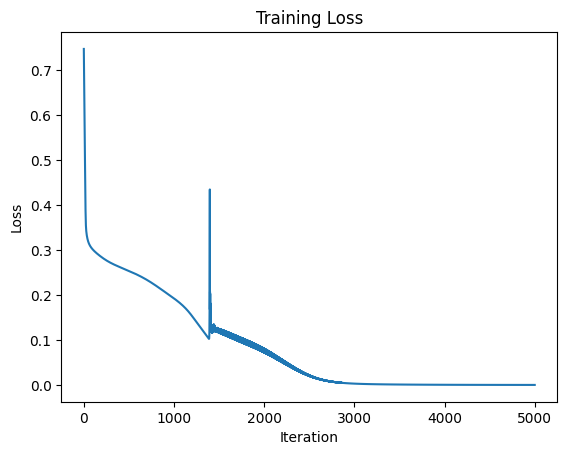

In [103]:
import torch
import torch.nn.functional as F

NUM_ATOM_TYPES = 5
NUM_BLOCKS = 1
HIDDEN_NF = 32
TANH_COORD_UPDATES = False
ATTENTION = False
AGGR_TYPE = "sum"

NUM_ITERS = 5000
LR = 0.02

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

real_mol = dataset[0]
print(f"Number of nodes: {real_mol.num_nodes}")
real_pos = real_mol.pos
# Zero center the real molecule positions
real_pos = real_pos - real_pos.mean(dim=0)
real_pos = real_pos / real_pos.std(dim=0)
real_pos = real_pos.to(device)
print(f"Center of mass of real molecule positions: {real_pos.mean(dim=0)}")
print(f"Std of real molecule positions: {real_pos.std(dim=0)}")

real_types = real_mol.real_atom_types
real_types = real_types.to(device)
print(f"Real molecule atom types shape: {real_types.shape}")
real_mol_combined = torch.cat([real_pos, real_types], dim=1)
print(f"Combined real molecule shape: {real_mol_combined.shape}")

# Sample noise once with the same shape
# as the real molecules
pos_noise = torch.randn_like(real_mol.pos, device=device)
pos_noise = pos_noise - pos_noise.mean(dim=0)
pos_noise = pos_noise / pos_noise.std(dim=0)
dense_edge_index = real_mol.dense_edge_index
dense_edge_index = dense_edge_index.to(device)
type_noise = torch.randn((real_mol.num_nodes, NUM_ATOM_TYPES), device=device)
combined_noise = torch.cat([pos_noise, type_noise], dim=1)
print(f"Combined noise shape: {combined_noise.shape}")
print()

# Instantiate model and optimizer
model = EGNN(
    num_atom_types=NUM_ATOM_TYPES,
    num_blocks=NUM_BLOCKS,
    hidden_nf=HIDDEN_NF,
    attention=ATTENTION,
    tanh_coord_updates=TANH_COORD_UPDATES,
    aggr_type=AGGR_TYPE,
)
model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()
    gen_pos, gen_types = model(pos_noise, type_noise, dense_edge_index)
    gen_mol_combined = torch.cat([gen_pos, gen_types], dim=1)
    V = real_mol_combined - gen_mol_combined
    gen_mol_drifted = (gen_mol_combined + V).detach()
    loss = F.mse_loss(gen_mol_drifted, gen_mol_combined)
    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 100 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")

plot_loss(loss_list)

In [104]:
gen_pos, gen_types, pos_list = model(
    pos_noise, type_noise, dense_edge_index, return_change_in_pos=True
)

In [109]:
print(f"Generated atom types (rounded): \n {gen_types.round()}")

Generated atom types (rounded): 
 tensor([[-0., 1., -0., -0., 0.],
        [1., -0., -0., -0., 0.],
        [1., -0., 0., -0., 0.],
        [1., 0., -0., -0., 0.],
        [1., 0., -0., 0., 0.]], device='cuda:0', grad_fn=<RoundBackward0>)


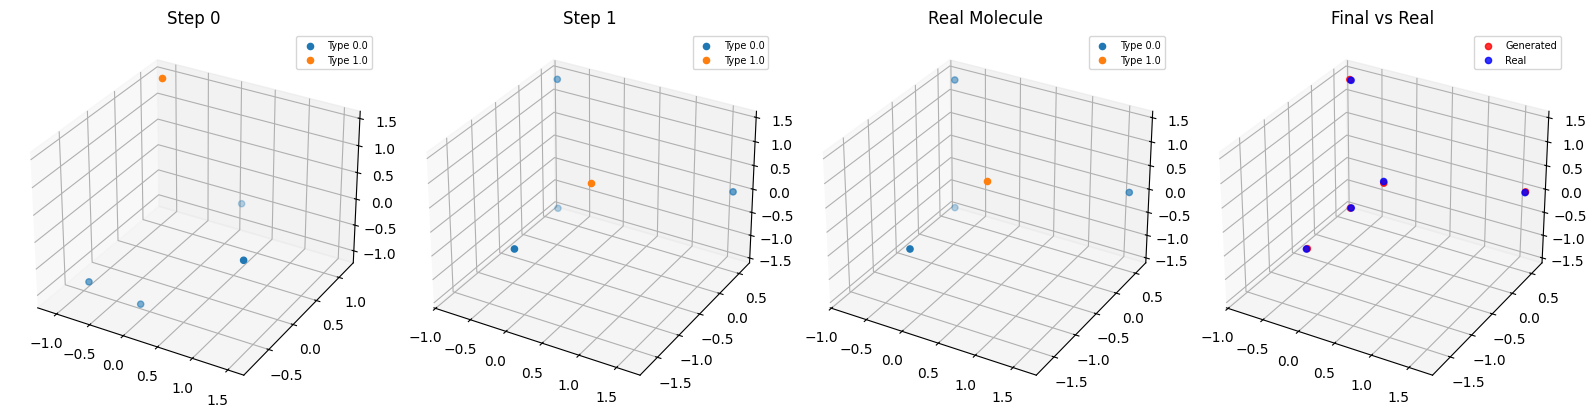

In [121]:
gen_types_argmax = gen_types.argmax(dim=1).float()
real_types_argmax = real_types.argmax(dim=1).float()

# pos_list is e.g. the trajectory saved during your diffusion reverse process
visualize_progression_with_real(
    pos_list=pos_list,
    gen_types=gen_types_argmax,
    real_pos=real_pos,
    real_types=real_types_argmax,
    max_steps=len(pos_list)        # shows 6 evenly-spaced snapshots + real on the right
)

# Sample Multiple Noise ONCE

Number of nodes: 5
Iter 99: Loss = 0.3207476735115051
Iter 199: Loss = 0.3069196939468384
Iter 299: Loss = 0.2976911962032318
Iter 399: Loss = 0.29071834683418274
Iter 499: Loss = 0.28457510471343994
Iter 599: Loss = 0.280011922121048
Iter 699: Loss = 0.2775109112262726
Iter 799: Loss = 0.27548059821128845
Iter 899: Loss = 0.27345073223114014
Iter 999: Loss = 0.27137821912765503
Iter 1099: Loss = 0.26923349499702454
Iter 1199: Loss = 0.2669847309589386
Iter 1299: Loss = 0.2645966708660126
Iter 1399: Loss = 0.26202723383903503
Iter 1499: Loss = 0.25922608375549316
Iter 1599: Loss = 0.25613850355148315
Iter 1699: Loss = 0.2527240812778473
Iter 1799: Loss = 0.24721094965934753
Iter 1899: Loss = 0.24553710222244263
Iter 1999: Loss = 0.24276934564113617
Iter 2099: Loss = 0.2400069385766983
Iter 2199: Loss = 0.23720915615558624
Iter 2299: Loss = 0.23436076939105988
Iter 2399: Loss = 0.23143401741981506
Iter 2499: Loss = 0.22840236127376556
Iter 2599: Loss = 0.22524787485599518
Iter 2699: Los

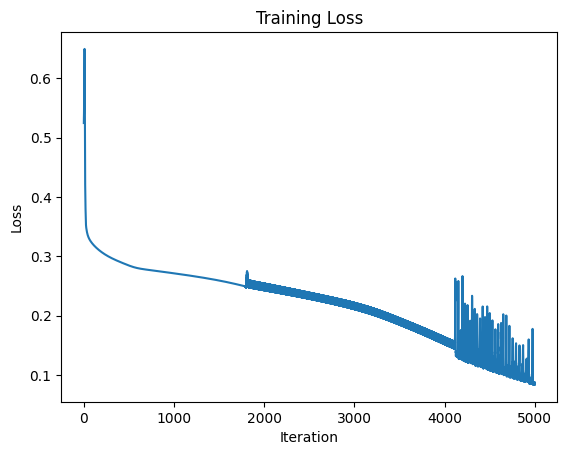

In [152]:
import torch
import torch.nn.functional as F

N_GEN_MOLS = 10

NUM_ATOM_TYPES = 5
NUM_BLOCKS = 1
HIDDEN_NF = 32
TANH_COORD_UPDATES = False
ATTENTION = False
AGGR_TYPE = "sum"

NUM_ITERS = 5000
LR = 0.02

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

real_mol = dataset[0]
print(f"Number of nodes: {real_mol.num_nodes}")
real_pos = real_mol.pos
# Zero center the real molecule positions
real_pos = real_pos - real_pos.mean(dim=0)
real_pos = real_pos / real_pos.std(dim=0)
real_pos = real_pos.to(device)

real_types = real_mol.real_atom_types
real_types = real_types.to(device)

real_mol_combined = torch.cat([real_pos, real_types], dim=1)

real_types_flattened = real_types.view(1, -1)
real_pos_flattened = real_pos.view(1, -1)

# Instantiate model and optimizer
model = EGNN(
    num_atom_types=NUM_ATOM_TYPES,
    num_blocks=NUM_BLOCKS,
    hidden_nf=HIDDEN_NF,
    attention=ATTENTION,
    tanh_coord_updates=TANH_COORD_UPDATES,
    aggr_type=AGGR_TYPE,
)
model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

# Sample noise once with the same shape
# as the real molecules
batch_vec = torch.arange(N_GEN_MOLS, device=device).repeat_interleave(real_mol.num_nodes)
pos_noise = torch.randn((N_GEN_MOLS * real_mol.num_nodes, 3), device=device)
pos_noise = center_positions_per_mol(pos_noise, batch_vec)
pos_noise = pos_noise / pos_noise.std(dim=0)
type_noise = torch.randn((N_GEN_MOLS * real_mol.num_nodes, NUM_ATOM_TYPES), device=device)

combined_noise = torch.cat([pos_noise, type_noise], dim=1)

dense_edge_index = real_mol.dense_edge_index
edge_index_list = []
for offset in range(N_GEN_MOLS):
    offset_edge_index = dense_edge_index + offset * real_mol.num_nodes
    edge_index_list.append(offset_edge_index)
dense_edge_index = torch.cat(edge_index_list, dim=1)
dense_edge_index = dense_edge_index.to(device)

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()
    gen_pos, gen_types = model(pos_noise, type_noise, dense_edge_index)
    gen_mol_combined = torch.cat([gen_pos, gen_types], dim=-1)

    # Reshape to get right positions
    gen_pos = gen_pos.view(N_GEN_MOLS, -1)
    gen_types = gen_types.view(N_GEN_MOLS, -1)

    V_pos = compute_drifting_field(gen_pos, real_pos_flattened)
    V_types = compute_drifting_field(gen_types, real_types_flattened)

    V_pos = V_pos.view(N_GEN_MOLS * real_mol.num_nodes, 3)
    V_types = V_types.view(N_GEN_MOLS * real_mol.num_nodes, NUM_ATOM_TYPES)
    V_combined = torch.cat([V_pos, V_types], dim=-1)

    gen_mol_drifted = (gen_mol_combined + V_combined).detach()
    loss = F.mse_loss(gen_mol_drifted, gen_mol_combined)
    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 100 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")

plot_loss(loss_list)

In [153]:
gen_pos, gen_types, pos_list = model(
    pos_noise, type_noise, dense_edge_index, return_change_in_pos=True
)

In [169]:
gen_types.round().pow(2).sum(dim=1)

tensor([1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 2., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 2., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 5., 1., 1., 1., 1., 1., 1., 1.],
       device='cuda:0', grad_fn=<SumBackward1>)

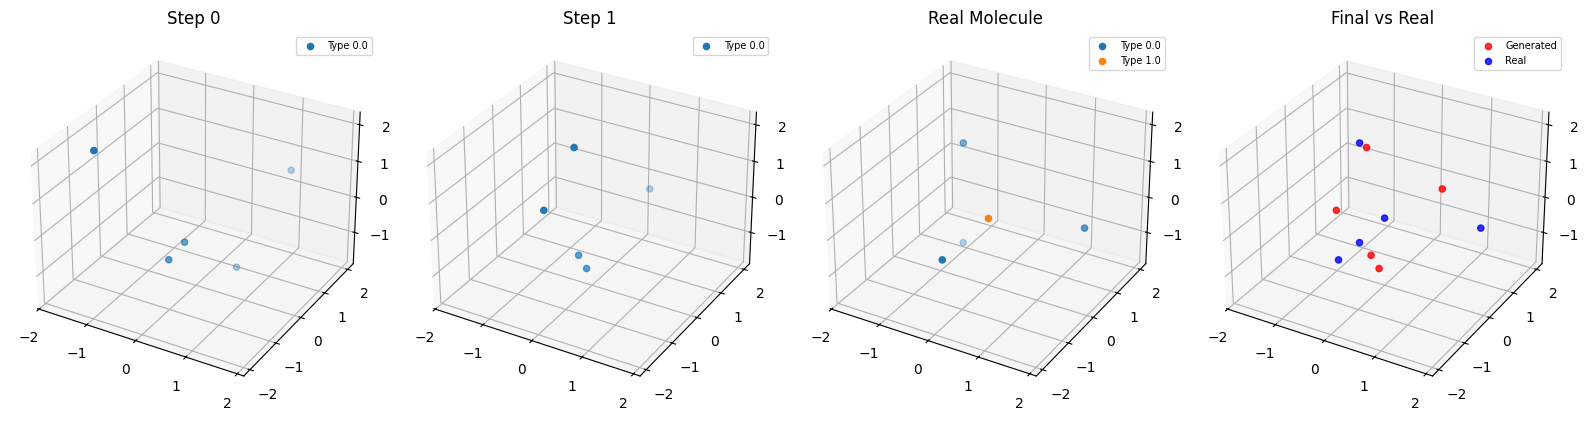

In [182]:
gen_pos_flattened = gen_pos.view(N_GEN_MOLS, -1)
sorted_pos, closest_indices = get_sorted_mols(gen_pos_flattened, real_pos_flattened)

SELECTED_IDX = 9

selected_pos_list = []
for gen_pos_step in pos_list:
    gen_pos_step_flattened = gen_pos_step.view(N_GEN_MOLS, -1)
    selected_gen_pos_step = gen_pos_step_flattened[SELECTED_IDX]
    selected_pos_list.append(selected_gen_pos_step.view(-1, 3))

viz_types = gen_types.reshape(N_GEN_MOLS, -1)
viz_types = viz_types[closest_indices[SELECTED_IDX]]

viz_types = viz_types.view(-1, NUM_ATOM_TYPES).argmax(dim=1).float()
real_types_argmax = real_types.view(-1, NUM_ATOM_TYPES).argmax(dim=1).float()

# pos_list is e.g. the trajectory saved during your diffusion reverse process
visualize_progression_with_real(
    pos_list=selected_pos_list,
    gen_types=viz_types,
    real_pos=real_pos,
    real_types=real_types_argmax,
    max_steps=len(selected_pos_list)
)

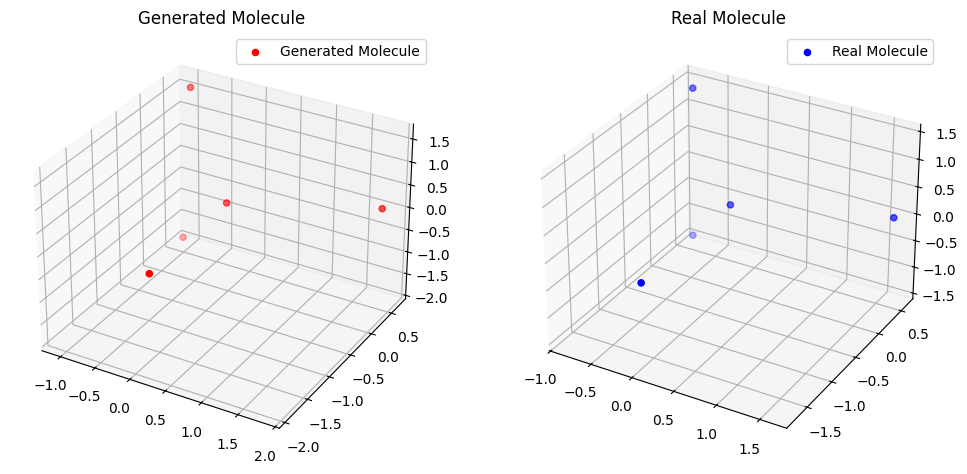

In [ ]:
sorted_mols, _ = get_sorted_mols(gen_mol, real_pos.unsqueeze(0))
visualize_both_molecules(sorted_mols[9].view(-1, 3), real_pos.view(-1, 3))

# Sample DIFFERENT noise every time

Number of nodes: 5
Iter 499: Loss = 1.0157642364501953
Iter 999: Loss = 0.9831550121307373
Iter 1499: Loss = 0.7706218361854553
Iter 1999: Loss = 0.6246938109397888
Iter 2499: Loss = 0.5060461163520813
Iter 2999: Loss = 0.42866250872612
Iter 3499: Loss = 0.3743332028388977
Iter 3999: Loss = 0.36626681685447693
Iter 4499: Loss = 0.2866996228694916
Iter 4999: Loss = 0.2729075849056244
Iter 5499: Loss = 0.2685152590274811
Iter 5999: Loss = 0.1858794093132019
Iter 6499: Loss = 0.17868980765342712
Iter 6999: Loss = 0.19099105894565582
Iter 7499: Loss = 0.13358688354492188
Iter 7999: Loss = 0.11979545652866364
Iter 8499: Loss = 0.12159059196710587
Iter 8999: Loss = 0.08302221447229385
Iter 9499: Loss = 0.07051222771406174
Iter 9999: Loss = 0.07324952632188797
Iter 10499: Loss = 0.05655067414045334
Iter 10999: Loss = 0.036108896136283875
Iter 11499: Loss = 0.0649903193116188
Iter 11999: Loss = 0.04492269083857536
Iter 12499: Loss = 0.04000759869813919
Iter 12999: Loss = 0.024394750595092773
I

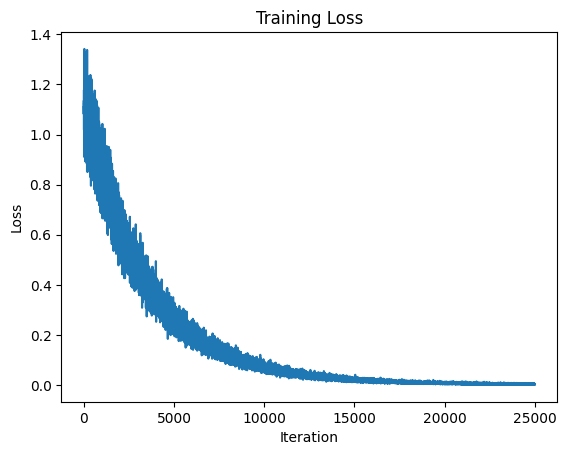

In [ ]:
import torch
import torch.nn.functional as F

NUM_ITERS = 25000
N_GEN_MOLS = 10
LR = 0.001

real_mol = dataset[0]
print(f"Number of nodes: {real_mol.num_nodes}")
real_pos = real_mol.pos
# Zero center the real molecule positions
real_pos = real_pos - real_pos.mean(dim=0)
real_pos = real_pos / real_pos.std(dim=0)
real_pos = real_pos.flatten()

# Instantiate model and optimizer
model = DummyModel(num_nodes=real_mol.num_nodes)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

# Train model
loss_list, model = train(
    model,
    optimizer,
    NUM_ITERS,
    N_GEN_MOLS,
    num_nodes=real_mol.num_nodes
)

plot_loss(loss_list)

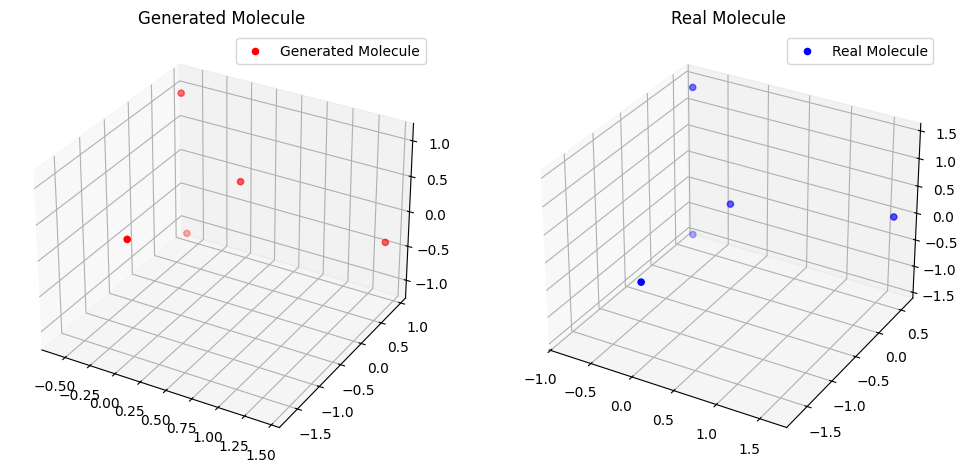

In [ ]:
noise = sample_pos_noise(N_GEN_MOLS, real_mol.num_nodes)
noise = noise.view(N_GEN_MOLS, -1)
gen_mol = model(noise)

sorted_mols, _ = get_sorted_mols(gen_mol.view(-1, 3), real_pos.view(-1, 3))
visualize_both_molecules(sorted_mols[9], real_pos)

# One Gen Mol and One Real Mol WITH Atom Types

Number of nodes: 5
Real molecule positions shape: torch.Size([5, 3])
Real molecule atom types shape: torch.Size([5, 5])
Combined real molecule shape: torch.Size([40])
Position noise shape: torch.Size([5, 3])
Combined noise shape: torch.Size([40])

Iter 99: Loss = 0.5600471496582031
Iter 199: Loss = 0.4228397011756897
Iter 299: Loss = 0.3192470669746399
Iter 399: Loss = 0.24103383719921112
Iter 499: Loss = 0.18198230862617493
Iter 599: Loss = 0.13739798963069916
Iter 699: Loss = 0.1037365049123764
Iter 799: Loss = 0.07832182198762894
Iter 899: Loss = 0.05913354828953743
Iter 999: Loss = 0.044646255671978
Iter 1099: Loss = 0.03370827063918114
Iter 1199: Loss = 0.025449994951486588
Iter 1299: Loss = 0.019214939326047897
Iter 1399: Loss = 0.014507418498396873
Iter 1499: Loss = 0.010953198187053204
Iter 1599: Loss = 0.008269750513136387
Iter 1699: Loss = 0.006243717856705189
Iter 1799: Loss = 0.004714058246463537
Iter 1899: Loss = 0.0035591486375778913
Iter 1999: Loss = 0.002687184605747461

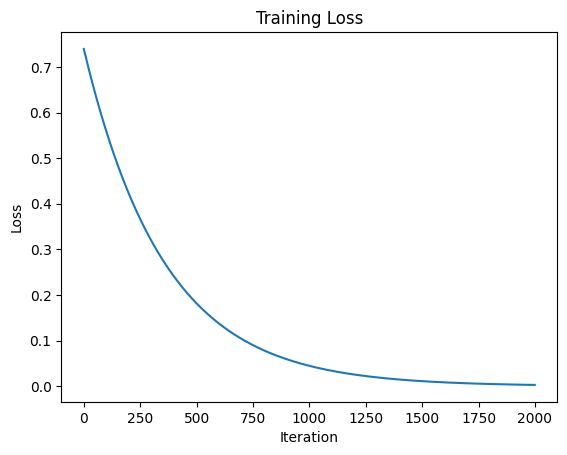

In [72]:
import torch
import torch.nn.functional as F

NUM_ITERS = 2000
NUM_ATOM_TYPES = 5
LR = 0.001

real_mol = dataset[0]
print(f"Number of nodes: {real_mol.num_nodes}")
real_pos = real_mol.pos
# Zero center the real molecule positions
real_pos = real_pos - real_pos.mean(dim=0)
real_pos = real_pos / real_pos.std(dim=0)
print(f"Real molecule positions shape: {real_pos.shape}")

real_types = real_mol.real_atom_types
print(f"Real molecule atom types shape: {real_types.shape}")
real_mol_combined = torch.cat([real_pos, real_types], dim=1)
real_mol_combined = real_mol_combined.flatten()
print(f"Combined real molecule shape: {real_mol_combined.shape}")

# Sample noise once but for multiple molecules
# as the real molecules
# This is the logic in sample noise above
pos_noise = torch.randn((real_mol.num_nodes, 3))
pos_noise = pos_noise - pos_noise.mean(dim=0)
pos_noise = pos_noise / pos_noise.std(dim=0)
print(f"Position noise shape: {pos_noise.shape}")

# We sample random noise as embedding for atom types
type_noise = torch.randn((real_mol.num_nodes, NUM_ATOM_TYPES))
combined_noise = torch.cat([pos_noise, type_noise], dim=1).flatten()
print(f"Combined noise shape: {combined_noise.shape}")
print()

# Instantiate model and optimizer
model = DummyModel(
    num_nodes=real_mol.num_nodes, num_atom_types=NUM_ATOM_TYPES
)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()
    gen_mol = model(combined_noise)
    V = real_mol_combined - gen_mol
    gen_mol_drifted = (gen_mol + V).detach()
    loss = F.mse_loss(gen_mol_drifted, gen_mol)
    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 100 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")

plot_loss(loss_list)


Generated atom types (rounded): 
 tensor([[-0., 1., 0., 0., -0.],
        [1., -0., -0., -0., 0.],
        [1., -0., -0., -0., 0.],
        [1., -0., 0., 0., 0.],
        [1., -0., 0., 0., -0.]], grad_fn=<RoundBackward0>)
torch.Size([5])


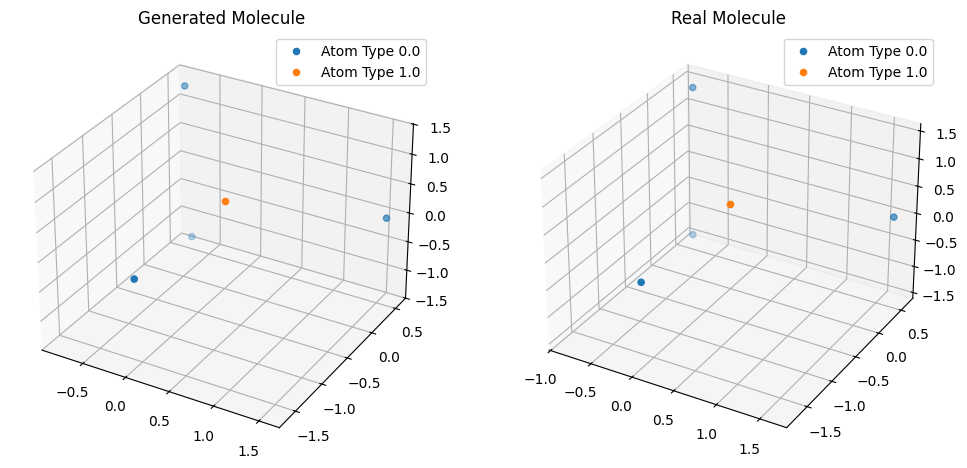

In [74]:
gen_pos, gen_types = gen_mol.view(
    real_mol.num_nodes, -1
).split([3, NUM_ATOM_TYPES], dim=1)

print(f"Generated atom types (rounded): \n {gen_types.round()}")

gen_types_argmax = gen_types.argmax(dim=1).float()
real_types_argmax = real_types.argmax(dim=1).float()

print(real_types_argmax.shape)

visualize_both_molecules_with_atom_types(
    gen_pos, gen_types_argmax, real_pos, real_types_argmax
)

# Atom Types + Pos | Multiple Noise and One Mol

Overfitting is possible with enough training time. Repulsion should not be a problem here.

Number of nodes: 5
Combined real molecule shape: torch.Size([40])
Position noise shape: torch.Size([50, 3])
Type noise shape: torch.Size([50, 5])
Combined noise shape: torch.Size([10, 40])

Iter 99: Loss = 0.5948534607887268
Iter 199: Loss = 0.5565013289451599
Iter 299: Loss = 0.5205962657928467
Iter 399: Loss = 0.48696067929267883
Iter 499: Loss = 0.4554285407066345
Iter 599: Loss = 0.42584601044654846
Iter 699: Loss = 0.3980737030506134
Iter 799: Loss = 0.37198635935783386
Iter 899: Loss = 0.3474729061126709
Iter 999: Loss = 0.3244354724884033
Iter 1099: Loss = 0.3027886152267456
Iter 1199: Loss = 0.2824574410915375
Iter 1299: Loss = 0.26337602734565735
Iter 1399: Loss = 0.24548529088497162
Iter 1499: Loss = 0.228731170296669
Iter 1599: Loss = 0.2130628526210785
Iter 1699: Loss = 0.19843131303787231
Iter 1799: Loss = 0.18478824198246002
Iter 1899: Loss = 0.17208534479141235
Iter 1999: Loss = 0.16027390956878662
Iter 2099: Loss = 0.14930495619773865
Iter 2199: Loss = 0.139129251241683

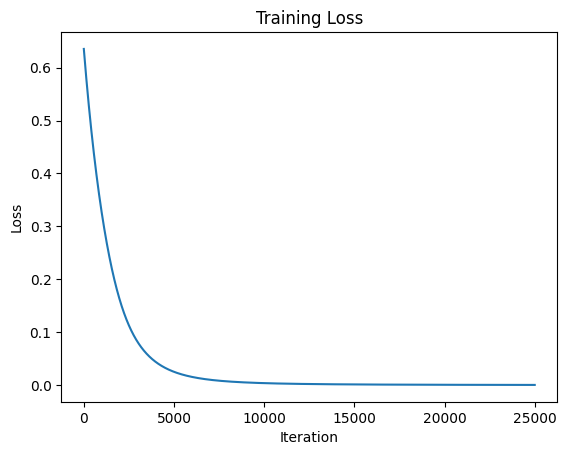

In [78]:
import torch
import torch.nn.functional as F

NUM_ITERS = 25000
N_GEN_MOLS = 10
NUM_ATOM_TYPES = 5
LR = 0.001

real_mol = dataset[0]
print(f"Number of nodes: {real_mol.num_nodes}")
real_pos = real_mol.pos
# Zero center the real molecule positions
real_pos = real_pos - real_pos.mean(dim=0)
real_pos = real_pos / real_pos.std(dim=0)
real_pos = real_pos.view(1, -1)

real_types = real_mol.real_atom_types.view(1, -1)
print(f"Combined real molecule shape: {real_mol_combined.shape}")

# Sample noise once with the same shape
# as the real molecules
pos_noise = sample_pos_noise(N_GEN_MOLS, real_mol.num_nodes)
type_noise = sample_type_noise(N_GEN_MOLS, real_mol.num_nodes, NUM_ATOM_TYPES)
print(f"Position noise shape: {pos_noise.shape}")
print(f"Type noise shape: {type_noise.shape}")
combined_noise = torch.cat([pos_noise, type_noise], dim=1)
combined_noise = combined_noise.view(N_GEN_MOLS, -1)
print(f"Combined noise shape: {combined_noise.shape}")
print()

# Instantiate model and optimizer
model = DummyModel(
    num_nodes=real_mol.num_nodes, num_atom_types=NUM_ATOM_TYPES
)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()

    gen_mol = model(combined_noise)

    # Reshape and split generated molecule into positions and atom types
    gen_mol_split = gen_mol.view(N_GEN_MOLS * real_mol.num_nodes, -1)
    gen_pos, gen_types = gen_mol_split.split([3, NUM_ATOM_TYPES], dim=1)

    # Reshape to get right positions
    gen_pos = gen_pos.reshape(N_GEN_MOLS, -1)
    gen_types = gen_types.reshape(N_GEN_MOLS, -1)

    V_pos = compute_drifting_field(gen_pos, real_pos)
    V_types = compute_drifting_field(gen_types, real_types)

    V_pos = V_pos.view(N_GEN_MOLS * real_mol.num_nodes, 3)
    V_types = V_types.view(N_GEN_MOLS * real_mol.num_nodes, NUM_ATOM_TYPES)
    V_combined = torch.cat([V_pos, V_types], dim=1)
    V_combined = V_combined.view(N_GEN_MOLS, -1)

    gen_mol_drifted = (gen_mol + V_combined).detach()
    loss = F.mse_loss(gen_mol_drifted, gen_mol)
    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 100 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")

plot_loss(loss_list)


Mean of rounded atom types: 1.0


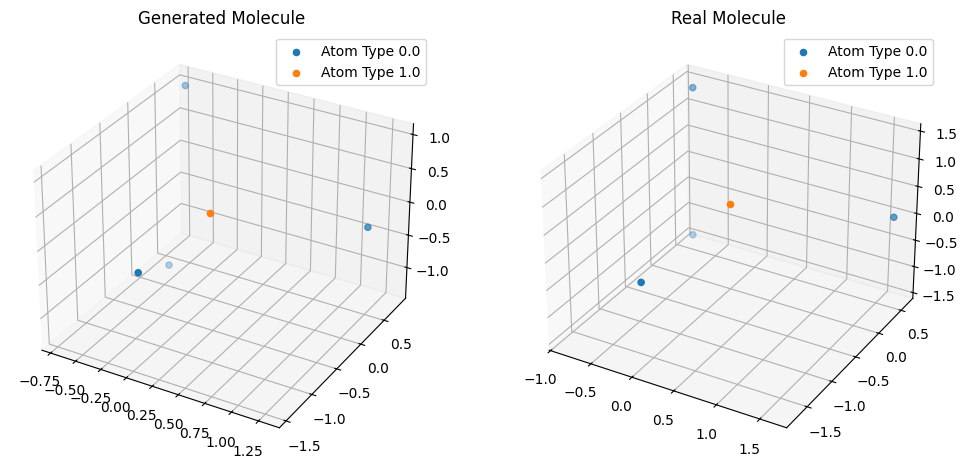

In [ ]:
gen_pos, gen_types = gen_mol.view(
    N_GEN_MOLS * real_mol.num_nodes, -1
).split([3, NUM_ATOM_TYPES], dim=1)

print(f"Mean of rounded atom types: {gen_types.round().sum(dim=1).mean().item()}")

sorted_pos, closest_indices = get_sorted_mols(
    gen_pos.reshape(N_GEN_MOLS, -1), real_pos
)

SELECTED_IDX = 9

viz_pos = sorted_pos[SELECTED_IDX].squeeze()
viz_types = gen_types.reshape(N_GEN_MOLS, -1)
viz_types = viz_types[closest_indices[SELECTED_IDX]]
viz_types = viz_types.view(-1, NUM_ATOM_TYPES).argmax(dim=1).float()

real_types_argmax = real_types.view(-1, NUM_ATOM_TYPES).argmax(dim=1).float()

visualize_both_molecules_with_atom_types(
    viz_pos.view(-1, 3), viz_types, real_pos.view(-1, 3), real_types_argmax
)

# Pos + Types | Different Noise Every Time

Number of nodes: 5
Combined real molecule shape: torch.Size([40])
Iter 99: Loss = 0.7120481729507446
Iter 199: Loss = 0.6479562520980835
Iter 299: Loss = 0.617200493812561
Iter 399: Loss = 0.6756860613822937
Iter 499: Loss = 0.6873117685317993
Iter 599: Loss = 0.686601996421814
Iter 699: Loss = 0.8294133543968201
Iter 799: Loss = 0.7824108004570007
Iter 899: Loss = 0.6966568231582642
Iter 999: Loss = 0.6402565240859985
Iter 1099: Loss = 0.7394413948059082
Iter 1199: Loss = 0.625499963760376
Iter 1299: Loss = 0.6306924819946289
Iter 1399: Loss = 0.5787439942359924
Iter 1499: Loss = 0.6077677607536316
Iter 1599: Loss = 0.6584140062332153
Iter 1699: Loss = 0.6161024570465088
Iter 1799: Loss = 0.632632851600647
Iter 1899: Loss = 0.6448901295661926
Iter 1999: Loss = 0.6501623392105103
Iter 2099: Loss = 0.5643665194511414
Iter 2199: Loss = 0.5894235968589783
Iter 2299: Loss = 0.5763906836509705
Iter 2399: Loss = 0.6329619884490967
Iter 2499: Loss = 0.5467102527618408
Iter 2599: Loss = 0.6014

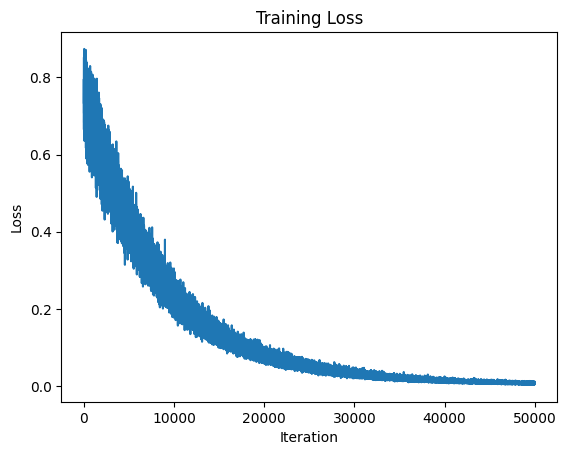

In [ ]:
import torch
import torch.nn.functional as F

NUM_ITERS = 50000
N_GEN_MOLS = 10
NUM_ATOM_TYPES = 5
LR = 0.001

real_mol = dataset[0]
print(f"Number of nodes: {real_mol.num_nodes}")
real_pos = real_mol.pos
# Zero center the real molecule positions
real_pos = real_pos - real_pos.mean(dim=0)
real_pos = real_pos / real_pos.std(dim=0)
real_pos = real_pos.view(1, -1)
real_types = real_mol.real_atom_types.view(1, -1)

# Instantiate model and optimizer
model = DummyModel(
    num_nodes=real_mol.num_nodes, num_atom_types=NUM_ATOM_TYPES
)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()

    # Sample noise as before
    pos_noise = sample_pos_noise(N_GEN_MOLS, real_mol.num_nodes)
    type_noise = sample_type_noise(N_GEN_MOLS, real_mol.num_nodes, NUM_ATOM_TYPES)
    combined_noise = torch.cat([pos_noise, type_noise], dim=1)
    combined_noise = combined_noise.view(N_GEN_MOLS, -1)


    gen_mol = model(combined_noise)

    # Reshape and split generated molecule into positions and atom types
    gen_mol_split = gen_mol.view(N_GEN_MOLS * real_mol.num_nodes, -1)
    gen_pos, gen_types = gen_mol_split.split([3, NUM_ATOM_TYPES], dim=1)

    # Reshape to get right positions
    gen_pos = gen_pos.reshape(N_GEN_MOLS, -1)
    gen_types = gen_types.reshape(N_GEN_MOLS, -1)

    V_pos = compute_drifting_field(gen_pos, real_pos)
    V_types = compute_drifting_field(gen_types, real_types)

    V_pos = V_pos.view(N_GEN_MOLS * real_mol.num_nodes, 3)
    V_types = V_types.view(N_GEN_MOLS * real_mol.num_nodes, NUM_ATOM_TYPES)
    V_combined = torch.cat([V_pos, V_types], dim=1)
    V_combined = V_combined.view(N_GEN_MOLS, -1)

    gen_mol_drifted = (gen_mol + V_combined).detach()
    loss = F.mse_loss(gen_mol_drifted, gen_mol)
    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 100 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")

plot_loss(loss_list)


Mean of rounded atom types: 1.0


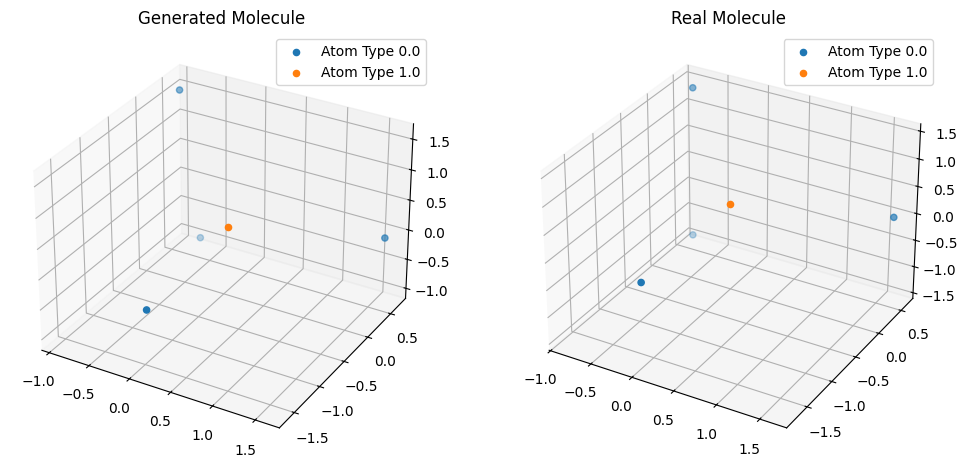

In [ ]:
gen_pos, gen_types = gen_mol.view(
    N_GEN_MOLS * real_mol.num_nodes, -1
).split([3, NUM_ATOM_TYPES], dim=1)

print(f"Mean of rounded atom types: {gen_types.round().sum(dim=1).mean().item()}")

sorted_pos, closest_indices = get_sorted_mols(
    gen_pos.reshape(N_GEN_MOLS, -1), real_pos
)

SELECTED_IDX = 0

viz_pos = sorted_pos[SELECTED_IDX].squeeze()
viz_types = gen_types.reshape(N_GEN_MOLS, -1)
viz_types = viz_types[closest_indices[SELECTED_IDX]]
viz_types = viz_types.view(-1, NUM_ATOM_TYPES).argmax(dim=1).float()

real_types_argmax = real_types.view(-1, NUM_ATOM_TYPES).argmax(dim=1).float()

visualize_both_molecules_with_atom_types(
    viz_pos.view(-1, 3), viz_types, real_pos.view(-1, 3), real_types_argmax
)

# Multiple Real Molecules with Same Number of atoms

Center of mass of real molecule positions: tensor([5.9605e-09, 2.3842e-08, 2.3842e-08])
Std of real molecule positions: tensor([1., 1., 1.])

Iter 99: Loss = 0.5367621183395386
Iter 199: Loss = 0.4646275043487549
Iter 299: Loss = 0.5086796283721924
Iter 399: Loss = 0.5088953375816345
Iter 499: Loss = 0.48539212346076965
Iter 599: Loss = 0.47407007217407227
Iter 699: Loss = 0.48679766058921814
Iter 799: Loss = 0.47280973196029663
Iter 899: Loss = 0.4719422459602356
Iter 999: Loss = 0.46364739537239075
Iter 1099: Loss = 0.4692598283290863
Iter 1199: Loss = 0.4633884131908417
Iter 1299: Loss = 0.43754392862319946
Iter 1399: Loss = 0.45183300971984863
Iter 1499: Loss = 0.42378291487693787
Iter 1599: Loss = 0.4179029166698456
Iter 1699: Loss = 0.4203188419342041
Iter 1799: Loss = 0.4048166573047638
Iter 1899: Loss = 0.4132544994354248
Iter 1999: Loss = 0.40372470021247864
Iter 2099: Loss = 0.3879316747188568
Iter 2199: Loss = 0.3918752372264862
Iter 2299: Loss = 0.38241854310035706
Iter 239

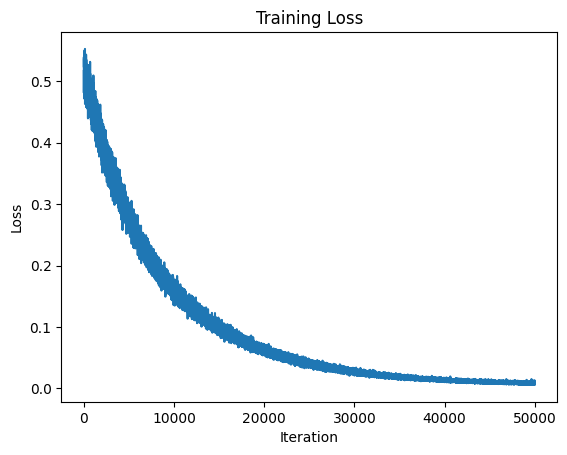

In [139]:
import torch
import torch.nn.functional as F

NUM_ITERS = 50000
N_GEN_MOLS = 100
N_REAL_MOLS = 2
NUM_ATOM_TYPES = 5
NUM_ATOMS = 5
LR = 0.001

keep = []
for i, d in enumerate(dataset):
    if d.num_nodes == NUM_ATOMS:
        keep.append(i)
    if len(keep) >= N_REAL_MOLS:
        break
filtered_dataset = dataset.index_select(keep)

batch_vec = torch.arange(N_REAL_MOLS).repeat_interleave(NUM_ATOMS)
real_pos = center_positions_per_mol(
    filtered_dataset.pos, batch_vec
)
real_pos = real_pos / real_pos.std(dim=0)
print(f"Center of mass of real molecule positions: {global_mean_pool(real_pos, batch_vec).mean(dim=0)}")
print(f"Std of real molecule positions: {real_pos.std(dim=0)}")
print()

real_pos = real_pos.view(N_REAL_MOLS, -1)
real_types = filtered_dataset.real_atom_types.view(N_REAL_MOLS, -1)

# Instantiate model and optimizer
model = DummyModel(
    num_nodes=NUM_ATOMS, num_atom_types=NUM_ATOM_TYPES
)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()

    # Sample noise as before
    pos_noise = sample_pos_noise(N_GEN_MOLS, NUM_ATOMS)
    type_noise = sample_type_noise(N_GEN_MOLS, NUM_ATOMS, NUM_ATOM_TYPES)
    combined_noise = torch.cat([pos_noise, type_noise], dim=1)
    combined_noise = combined_noise.view(N_GEN_MOLS, -1)


    gen_mol = model(combined_noise)

    # Reshape and split generated molecule into positions and atom types
    gen_mol_split = gen_mol.view(N_GEN_MOLS * NUM_ATOMS, -1)
    gen_pos, gen_types = gen_mol_split.split([3, NUM_ATOM_TYPES], dim=1)

    # Reshape to get right positions
    gen_pos = gen_pos.reshape(N_GEN_MOLS, -1)
    gen_types = gen_types.reshape(N_GEN_MOLS, -1)

    V_pos = compute_drifting_field(gen_pos, real_pos)
    V_types = compute_drifting_field(gen_types, real_types)

    V_pos = V_pos.view(N_GEN_MOLS * NUM_ATOMS, 3)
    V_types = V_types.view(N_GEN_MOLS * NUM_ATOMS, NUM_ATOM_TYPES)
    V_combined = torch.cat([V_pos, V_types], dim=1)
    V_combined = V_combined.view(N_GEN_MOLS, -1)

    gen_mol_drifted = (gen_mol + V_combined).detach()
    loss = F.mse_loss(gen_mol_drifted, gen_mol)
    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 100 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")

plot_loss(loss_list)


Mean of rounded atom types: 0.9639999866485596
Rounded viz types: 
 tensor([[ 0.,  1.,  0.,  0.,  0.],
        [ 0.,  1., -0., -0.,  0.],
        [ 0.,  1., -0., -0.,  0.],
        [ 1.,  0., -1.,  0., -0.],
        [ 0., -0.,  1.,  0., -0.]], grad_fn=<RoundBackward0>)


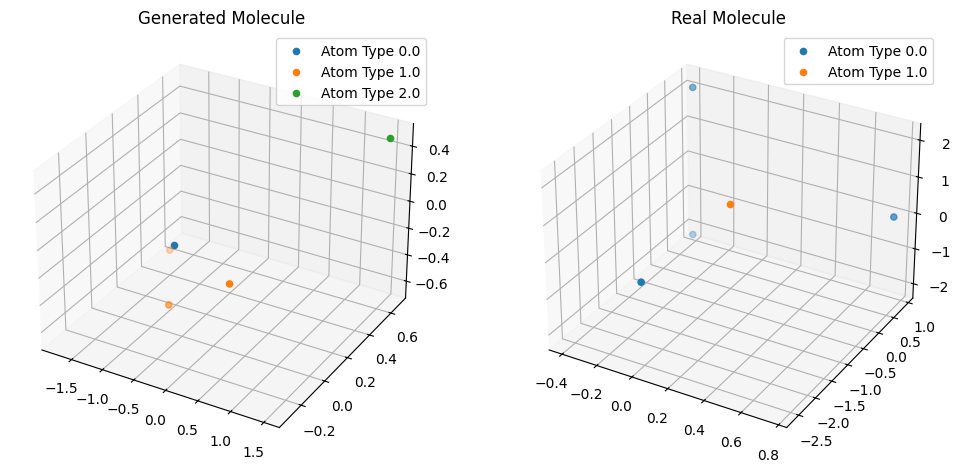

In [141]:
REAL_MOL_IDX = 0

selected_real_pos = real_pos[REAL_MOL_IDX].view(1, -1)
selected_real_types = real_types[REAL_MOL_IDX].view(1, -1)

gen_pos, gen_types = gen_mol.view(
    N_GEN_MOLS * NUM_ATOMS, -1
).split([3, NUM_ATOM_TYPES], dim=1)

print(f"Mean of rounded atom types: {gen_types.round().sum(dim=1).mean().item()}")

sorted_pos, closest_indices = get_sorted_mols(
    gen_pos.reshape(N_GEN_MOLS, -1), selected_real_pos
)

SELECTED_IDX = 0

viz_pos = sorted_pos[SELECTED_IDX].squeeze()
viz_types = gen_types.reshape(N_GEN_MOLS, -1)
viz_types = viz_types[closest_indices[SELECTED_IDX]]
viz_types = viz_types.view(-1, NUM_ATOM_TYPES)
print(f"Rounded viz types: \n {viz_types.round()}")
viz_types = viz_types.argmax(dim=1).float()

real_types_argmax = selected_real_types.view(-1, NUM_ATOM_TYPES).argmax(dim=1).float()

visualize_both_molecules_with_atom_types(
    viz_pos.view(-1, 3), viz_types, selected_real_pos.view(-1, 3), real_types_argmax
)